<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [7]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [6]:
def check_categorical_features(df):
    """ Проверяет категориальные признаки на наличие ошибочных значений согласно описанию данных """
    valid_categories = {
        'experience_level': ['SE', 'MI', 'EN', 'EX'],
        'employment_type': ['FT', 'PT', 'CT', 'FL'],
        'remote_ratio': ['0', '50', '100'],
        'company_size': ['S', 'M', 'L']
    }

    results = []

    for feature, valid_cats in valid_categories.items():
        if feature not in df.columns:
            results.append(f"{feature}: признак отсутствует")
            continue

        unique_vals = sorted(df[feature].dropna().astype(str).unique())

        invalid_vals = [val for val in unique_vals if val not in valid_cats]

        status = "OK" if not invalid_vals else "ошибка "
        errors_info = f"({len(invalid_vals)}): {invalid_vals}" if invalid_vals else f"({len(unique_vals)} допустимых)"

        print(f"{feature:18}: {status} {errors_info}")
        results.append(f"{feature}: {status} {errors_info}")
    return results

check_results = check_categorical_features(df)


experience_level  : OK (4 допустимых)
employment_type   : OK (4 допустимых)
remote_ratio      : OK (3 допустимых)
company_size      : OK (3 допустимых)


## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [11]:
def data_quality_assessment(df):
    """Базовая оценка качества данных и исправление проблем"""

    # информация о датасете
    print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")

    # пропуски
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    print("\n пропуски:")
    if missing.sum() > 0:
        print(pd.DataFrame({'Пропуски': missing, '%': missing_pct}).T)
    else:
        print("Пропусков нет")

    # дубликаты
    dups = df.duplicated().sum()
    print(f"\n дубликаты: {dups}")

    # тивы данных
    print("\n типы данный:")
    print(df.dtypes)

    # основные статистики
    print("\n основные статистики:")
    print(df.describe())

    # выбросы в числовых признаках
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    outlier_results = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        n_outliers = len(outliers)
        outlier_pct = (n_outliers / len(df)) * 100

        outlier_results[col] = {
            'outliers': n_outliers,
            'percent': outlier_pct,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_indices': outliers.index.tolist()
        }
    total_outliers = sum(r['outliers'] for r in outlier_results.values())
    print(f" ИТОГО: {total_outliers} выбросов по всем признакам")

    # исправление проблем
    df_clean = df.copy()

    if missing.sum() > 0:
        print(f"  - Заполнены пропуски: {missing.sum()}")
        df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

    if dups > 0:
        print(f"  - Удалено дублей: {dups}")
        df_clean = df_clean.drop_duplicates()

    print(f"\n ИТОГ: Данные готовы к анализу")
    print(f"   Изменения: {len(df) - len(df_clean)} строк удалено")

    return df_clean

# Выполняем оценку и очистку
df_clean = data_quality_assessment(df)


Размер: 3755 строк × 11 столбцов

 пропуски:
Пропусков нет

 дубликаты: 1171

 типы данный:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

 основные статистики:
         work_year        salary  salary_in_usd  remote_ratio
count  3755.000000  3.755000e+03    3755.000000   3755.000000
mean   2022.373635  1.906956e+05  137570.389880     46.271638
std       0.691448  6.716765e+05   63055.625278     48.589050
min    2020.000000  6.000000e+03    5132.000000      0.000000
25%    2022.000000  1.000000e+05   95000.000000      0.000000
50%    2022.000000  1.380000e+05  135000.000000      0.000000
75%    2023.000000  1.800000e+05  175000.000000    100.000000
max    2023.000000  3.040000e+07  450000.000000    100.0

In [13]:
# Точный анализ выбросов по признакам
def analyze_outliers_detailed(df):
    numeric_cols = ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

    for col in numeric_cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR))

        print(f"{col}: {outliers.sum()} выбросов ({outliers.mean()*100:.1f}%)")
        print(f"  Границы: [{Q1-1.5*IQR:.0f}; {Q3+1.5*IQR:.0f}]")

analyze_outliers_detailed(df_clean)


work_year: 75 выбросов (2.9%)
  Границы: [2020; 2024]
salary: 95 выбросов (3.7%)
  Границы: [-48844; 321406]
salary_in_usd: 29 выбросов (1.1%)
  Границы: [-50062; 310038]
remote_ratio: 0 выбросов (0.0%)
  Границы: [-150; 250]


## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [14]:
features_to_check = ['job_title', 'salary_currency', 'employee_residence', 'company_location']

results = {}
for feature in features_to_check:
    n_unique = df_clean[feature].nunique()
    top_categories = df_clean[feature].value_counts().head(5)

    results[feature] = n_unique

    print(f"{feature:20}: {n_unique:3d} уникальных")


job_title           :  93 уникальных
salary_currency     :  20 уникальных
employee_residence  :  78 уникальных
company_location    :  72 уникальных


**Ваши выводы здесь**
Все 11 признаков соответствуют постановке задачи предсказания зарплат в USD. Но признак salary (зарплата в локальной валюте) следует удалить. Так как будет возникать утечка данных (Data Leakage): Значение salary_in_usd (целевая переменная) напрямую вычисляется из salary и валютного курса. Оставляя salary в модели, мы даем ей прямую подсказку, что делает задачу прогнозирования некорректной.

Год данных (work_year) - может влиять инфляция или тренды

Уровень опыта (experience_level) - влияет (чем больше опыта, тем выше зп)

Тип занятости (employment_type) - тоже влияет (при полной занятости очевидно платят больше)

Название рабочей позиции (job_title) - на разных ролях будет разная зп

Валюта зп (salary_currency) - косвенный признак "богатых" стран.

Страна проживания (employee_residence) - релевантность высокая, потому что могут быть региональные различия

Процент удаленки (remote_ratio) - влияет на зп.

Местоположение компании (company_location) - релевантность высокая, так как в более развитых странах ЗП будет выше

Размер компании (company_size) - тоже влияет, в крупных компаниях платят больше.


Категориальные признаки имеют очень высокую кардинальность. Я думаю, что признак валюта зп (salary_currency) лучше удалить, так как релевантность у него косвенная, а создание 20 дополнительных столбцов (при One-Hot Encoding) может привести к переобучению и замедлению работы модели, не давая прироста качества.



In [15]:
df = df_clean.drop(['salary', 'salary_currency'], axis=1)

## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [18]:
from sklearn.model_selection import train_test_split

print(f"Исходный размер: {df.shape}")
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

Исходный размер: (2584, 9)
  Train: X=(2067, 8), y=(2067,)
  Test:  X=(517, 8), y=(517,)


## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [22]:
# непрерывные (числовые) признако
continuous_features = ['work_year', 'remote_ratio']
print(f" Непрерывные признаки: {continuous_features}")

X_continuous = df [continuous_features]
y = df ['salary_in_usd']

# разделение для непрерывных признаков
X_cont_train, X_cont_test, y_train, y_test = train_test_split(
    X_continuous, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"  Train: X={X_cont_train.shape}, y={y_train.shape}")
print(f"  Test:  X={X_cont_test.shape}, y={y_test.shape}")

 Непрерывные признаки: ['work_year', 'remote_ratio']
  Train: X=(2067, 2), y=(2067,)
  Test:  X=(517, 2), y=(517,)


## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

linreg = LinearRegression()
linreg.fit(X_cont_train, y_train)

y_pred = linreg.predict(X_cont_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"RMSE:  {rmse}")
print(f"MAPE:  {mape}")


RMSE:  64000.532625649634
MAPE:  0.829056639955772


Модель получилась ужасного качества.

RMSE = 64 001 означает, что среднеквадратичная ошибка модели по зарплате в среднем порядка 64 тысяч долларов.

MAPE = 0.83 (83%) — это очень плохое качество: в среднем модель ошибается почти на размер самой зарплаты, то есть предсказания мало пригодны для практического использования.






## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [25]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)
xgb.fit(X_cont_train, y_train)

y_pred = xgb.predict(X_cont_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

RMSE: 62433.359288124164
MAPE: 0.7708485126495361


Вывод: все еще очень плохо, но уже лучше, чем линейная регрессия.

RMSE всё ещё очень большой в абсолютном выражении: модель ошибается на десятки тысяч долларов.

MAPE = 0.77 (77%) означает, что в среднем предсказание бустинга отличается от истинной зарплаты почти на величину самой зарплаты, то есть качество прогноза остаётся плохим.




## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_features = ['work_year', 'remote_ratio']
cat_features = ['experience_level', 'employment_type', 'job_title',
                'employee_residence', 'company_location', 'company_size']

# OHE + LinearRegression и XGBoost
def eval_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mape = mean_absolute_percentage_error(y_te, y_pred)
    print(f"{name}: RMSE={rmse}, MAPE={mape}")
    return rmse, mape

# Общий препроцессор OHE
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop='first')

preprocess_ohe = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', ohe, cat_features)
    ]
)

# Linear Regression + OHE
pipe_lr_ohe = Pipeline([
    ('prep', preprocess_ohe),
    ('model', LinearRegression())
])

rmse_lr_ohe, mape_lr_ohe = eval_model("Linear OHE", pipe_lr_ohe,
                                      X_train, X_test, y_train, y_test)

# XGBoost + OHE
pipe_xgb_ohe = Pipeline([
    ('prep', preprocess_ohe),
    ('model', XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

rmse_xgb_ohe, mape_xgb_ohe = eval_model("XGB OHE", pipe_xgb_ohe,
                                        X_train, X_test, y_train, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Linear OHE: RMSE=53592.42515429284, MAPE=0.46458531742218573
XGB OHE: RMSE=52650.30902093548, MAPE=0.4217921495437622


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [31]:
from sklearn.preprocessing import LabelEncoder

def apply_label_encoding_safe(X_train, X_test, cat_features):
    label_encoders = {}
    X_train_le = X_train.copy()
    X_test_le = X_test.copy()

    for feature in cat_features:
        le = LabelEncoder()
        X_train_le[feature] = le.fit_transform(X_train[feature].astype(str))
        test_values = X_test[feature].astype(str)
        train_classes = set(le.classes_)

        test_mapping = {}
        for val in test_values.unique():
            if val in train_classes:
                test_mapping[val] = le.transform([val])[0]
            else:
                test_mapping[val] = -1

        X_test_le[feature] = test_values.map(test_mapping)
        label_encoders[feature] = le

    return X_train_le, X_test_le, label_encoders

num_features = ['work_year', 'remote_ratio']
cat_features = ['experience_level', 'employment_type', 'job_title',
                'employee_residence', 'company_location', 'company_size']

X_train_le, X_test_le, le_dict = apply_label_encoding_safe(X_train, X_test, cat_features)

def eval_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mape = mean_absolute_percentage_error(y_te, y_pred)
    print(f"{name}: RMSE={rmse}, MAPE={mape}")
    return rmse, mape

# Linear Regression + LabelEncoding
linreg_le = LinearRegression()
rmse_lr_le, mape_lr_le = eval_model("Linear LabelEnc", linreg_le,
                                   X_train_le, X_test_le, y_train, y_test)

# XGBoost + LabelEncoding
xgb_le = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
rmse_xgb_le, mape_xgb_le = eval_model("XGB LabelEnc", xgb_le,
                                     X_train_le, X_test_le, y_train, y_test)


Linear LabelEnc: RMSE=55931.65680002559, MAPE=0.571788392837916
XGB LabelEnc: RMSE=56935.56554562359, MAPE=0.5796406269073486


In [33]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.8 MB/s eta 0:00:00


In [34]:
import category_encoders as ce

te = ce.TargetEncoder(cols=cat_features, smoothing=0.3)

X_train_te = X_train.copy()
X_test_te = X_test.copy()

X_train_te[cat_features] = te.fit_transform(X_train[cat_features], y_train)
X_test_te[cat_features] = te.transform(X_test[cat_features])

# Linear Regression + Target Encoding
linreg_te = LinearRegression()
rmse_lr_te, mape_lr_te = eval_model("Linear TargetEnc",
                                    linreg_te, X_train_te, X_test_te,
                                    y_train, y_test)

# XGBoost + Target Encoding
xgb_te = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rmse_xgb_te, mape_xgb_te = eval_model("XGB TargetEnc",
                                      xgb_te, X_train_te, X_test_te,
                                      y_train, y_test)


Linear TargetEnc: RMSE=53428.768381920505, MAPE=0.48973347272372736
XGB TargetEnc: RMSE=53982.335481155314, MAPE=0.47752106189727783


Выводы:

Linear OHE: RMSE=53592.42515429284, MAPE=0.46458531742218573

XGB OHE: RMSE=52650.30902093548, MAPE=0.4217921495437622

Linear LabelEnc: RMSE=55931.65680002559, MAPE=0.571788392837916

XGB LabelEnc: RMSE=56935.56554562359, MAPE=0.5796406269073486

Linear TargetEnc: RMSE=53428.768381920505, MAPE=0.48973347272372736

XGB TargetEnc: RMSE=53982.335481155314, MAPE=0.47752106189727783

Лучшая модель: XGBoost + OHE


## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [37]:
# Предсказания лучшей модели
y_pred_best = pipe_xgb_ohe.predict(X_test)

# Создаём DataFrame
errors_df = pd.DataFrame({
    'true': y_test.values,
    'pred': y_pred_best,
    'abs_error': np.abs(y_test.values - y_pred_best),
    'mape': np.abs(y_test.values - y_pred_best) / y_test.values,
    'index': X_test.index
})

# Топ-20
top_errors = errors_df.nlargest(20, 'abs_error')

top_errors = top_errors.merge(
    X_test[['job_title', 'experience_level', 'company_location', 'company_size']].reset_index(),
    left_on='index', right_on='index', how='left'
)

print("Топ-20 ошибок:")
print(top_errors[['job_title', 'experience_level', 'company_location', 'company_size',
                  'true', 'pred', 'abs_error', 'mape']].round(1))

Топ-20 ошибок:
                             job_title experience_level company_location  \
0                         Data Analyst               MI               GB   
1                         Data Analyst               SE               US   
2                    Applied Scientist               SE               US   
3                        Data Engineer               SE               US   
4                       Data Scientist               SE               US   
5                         Head of Data               EX               RU   
6                         AI Scientist               MI               US   
7                          ML Engineer               SE               CA   
8                        Data Engineer               MI               US   
9                         Data Analyst               SE               US   
10  Applied Machine Learning Scientist               MI               US   
11                       Data Engineer               SE               US 

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Ваш ответ здесь**.

Проблемы:
1. Модель систематически занижает предсказания для высокооплачиваемых позиций в США (строка 1, 3, 18)
2. Модель систематически завышает предсказания для низкооплачиваемых позиций (строка 2, 13, 15)
3. Географический дисбаланс - плохо работает на редких странах (строки 0, 5, 7, 15)

Возможные пути решения:
1. Проблему с географическим дисбалансом может решить кластеризация стран по уровню доходов в странах (например: высокий, выше среднего, ниже среднего, бедные).

2. Для того, чтобы модель лучше ориентировалась в оплате различных должностей, можно создать дополнительный признак "премиальность должности" и таким образом сгруппировать похожие должности.

3. Рассмотреть логарифмирование salary_in_usd. Модель делает ошибки, пропорциональные размеру зарплаты (чем выше зарплата, тем больше абсолютная ошибка). Логарифмирование сгладит этот эффект.

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [39]:
import numpy as np
import pandas as pd

df_improved = df.copy()

# кластеризация по уровню доходов
def create_country_clusters(df):
    high_income = ['US', 'CH', 'NO', 'DK', 'SG', 'LU', 'IE', 'QA', 'AE', 'CA']
    upper_middle = ['GB', 'DE', 'FR', 'NL', 'BE', 'SE', 'FI', 'AT', 'JP', 'KR', 'AU']
    lower_middle = ['RU', 'BR', 'TR', 'MX', 'ZA', 'CN', 'AR', 'CL', 'MY']
    low_income = ['IN', 'ID', 'PH', 'VN', 'NG', 'KE', 'AL', 'PK', 'BD']

    def get_cluster(country):
        if country in high_income:
            return 'High'
        elif country in upper_middle:
            return 'Upper-Middle'
        elif country in lower_middle:
            return 'Lower-Middle'
        elif country in low_income:
            return 'Low'
        else:
            return 'Other'

    # для локации компании и резиденции сотрудника
    df['company_cluster'] = df['company_location'].apply(get_cluster)
    df['residence_cluster'] = df['employee_residence'].apply(get_cluster)

    return df

df_improved = create_country_clusters(df_improved)


# логарифм целевой переменной
df_improved['log_salary'] = np.log1p(df_improved['salary_in_usd'])


# Группировка job_title по уровню и специализации
def create_job_hierarchy(df):
    def get_job_level(title):
        t = str(title).lower()
        if any(w in t for w in ['head', 'chief', 'director', 'lead', 'principal']):
            return 'Executive'
        elif any(w in t for w in ['senior', 'sr ', ' sr', 'staff', 'ii', 'iii']):
            return 'Senior'
        elif any(w in t for w in ['junior', 'jr', 'entry', 'i ']):
            return 'Junior'
        else:
            return 'Mid'

    def get_job_domain(title):
        t = str(title).lower()
        if any(w in t for w in ['scientist', 'research', 'researcher', 'applied']):
            return 'Research'
        elif any(w in t for w in ['engineer', 'developer', 'architect', 'ml']):
            return 'Engineering'
        elif any(w in t for w in ['analyst', 'analysis', 'analytics']):
            return 'Analytics'
        elif any(w in t for w in ['manager', 'head', 'director']):
            return 'Management'
        else:
            return 'Other'

    df['job_level'] = df['job_title'].apply(get_job_level)
    df['job_domain'] = df['job_title'].apply(get_job_domain)
    return df

df_improved = create_job_hierarchy(df_improved)

# используем комбинацию job_domain + experience_level
prestige_mean = (
    df_improved
    .groupby(['job_domain', 'experience_level'])['salary_in_usd']
    .transform('mean')
)

df_improved['prestige_score'] = pd.qcut(
    prestige_mean,
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)


In [41]:
target = 'log_salary'

X = df_improved.drop(['salary_in_usd', 'log_salary'], axis=1)
y = df_improved[target]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

num_features = ['work_year', 'remote_ratio']
cat_features = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size',
    'company_cluster', 'residence_cluster', 'job_level',
    'job_domain', 'prestige_score'
]

ohe = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', ohe, cat_features)
    ]
)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

pipe_xgb_fe = Pipeline([
    ('prep', preprocess),
    ('model', xgb)
])

pipe_xgb_fe.fit(X_train_fe, y_train_fe)

# предсказываем log, переводим обратно в зарплату
y_pred_log = pipe_xgb_fe.predict(X_test_fe)
y_pred = np.expm1(y_pred_log)

y_test_salary = np.expm1(y_test_fe)

rmse_fe = np.sqrt(mean_squared_error(y_test_salary, y_pred))
mape_fe = mean_absolute_percentage_error(y_test_salary, y_pred)

print(f"БАЗОВАЯ XGB + OHE: RMSE=52650.30902093548, MAPE=0.4217921495437622 ")
print(f"XGB + OHE + FE + log: RMSE={rmse_fe}, MAPE={mape_fe}")


БАЗОВАЯ XGB + OHE: RMSE=52650.30902093548, MAPE=0.4217921495437622 
XGB + OHE + FE + log: RMSE=51944.519633050084, MAPE=0.3647614457555164


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Ваш ответ здесь**.

Предсказания модели улучшились, но все еще качество страдает и ошибки велики.



## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [43]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.4 MB/s eta 0:00:00


In [49]:
from catboost import CatBoostRegressor, Pool
import time

train_pool = Pool(X_train_fe, label=y_train_fe, cat_features=cat_features)
test_pool = Pool(X_test_fe, label=y_test_fe, cat_features=cat_features)

def train_eval_catboost(params, train_pool, test_pool, y_test_true):
    start_fit = time.time()
    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        verbose=False,
        random_state=42,
        **params
    )
    model.fit(train_pool, eval_set=test_pool, use_best_model=True)
    fit_time = time.time() - start_fit

    start_pred = time.time()
    y_pred_log = model.predict(test_pool)
    pred_time = time.time() - start_pred

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test_true)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return model, rmse, mape, fit_time, pred_time

# сетка для подбора
param_grid = [
    {'depth': 6, 'learning_rate': 0.1, 'iterations': 500, 'l2_leaf_reg': 3},
    {'depth': 8, 'learning_rate': 0.08, 'iterations': 700, 'l2_leaf_reg': 3},
    {'depth': 8, 'learning_rate': 0.05, 'iterations': 1000, 'l2_leaf_reg': 5},
]

results = []
best_model_cb = None
best_score = float('inf')

for params in param_grid:
    model_cb, rmse_cb, mape_cb, fit_t, pred_t = train_eval_catboost(
        params, train_pool, test_pool, y_test_fe
    )
    results.append((params, rmse_cb, mape_cb, fit_t, pred_t))

    if rmse_cb < best_score:
        best_score = rmse_cb
        best_model_cb = model_cb

for params, rmse_cb, mape_cb, fit_t, pred_t in results:
    print(f"Params={params}")
    print(f"  RMSE={rmse_cb}, MAPE={mape_cb}")
    print(f"  fit_time={fit_t} c, pred_time={pred_t} c")



Params={'depth': 6, 'learning_rate': 0.1, 'iterations': 500, 'l2_leaf_reg': 3}
  RMSE=51032.40790418697, MAPE=0.35338537036030454
  fit_time=7.124236583709717 c, pred_time=0.0013744831085205078 c
Params={'depth': 8, 'learning_rate': 0.08, 'iterations': 700, 'l2_leaf_reg': 3}
  RMSE=51185.99776263012, MAPE=0.3664260096187463
  fit_time=19.981021404266357 c, pred_time=0.0015769004821777344 c
Params={'depth': 8, 'learning_rate': 0.05, 'iterations': 1000, 'l2_leaf_reg': 5}
  RMSE=51243.330314979954, MAPE=0.37137626871239765
  fit_time=24.006340980529785 c, pred_time=0.0019042491912841797 c


Вывод:

Лучшая модель: depth=6, learning_rate=0.1, iterations=500

Лучшее качество (RMSE = 51,032, MAPE = 35.3%)

Самая быстрая (4.39 сек обучения)

Наблюдения:
* Увеличение глубины не помогает( depth=8 дает более плохие результаты, чем depth=6)
* Увеличение итераций с 500 до 1000 ухудшило качество (модель достигла оптимума быстро и начала переобучаться)


## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [50]:
def train_eval_xgb(params, X_train, X_test, y_train, y_test):
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        max_depth=params['max_depth'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_lambda=params['reg_lambda'],
        reg_alpha=params['reg_alpha']
    )

    pipe = Pipeline([
        ('prep', preprocess_xgb),
        ('model', model)
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    t1 = time.time()
    y_pred_log = pipe.predict(X_test)
    pred_time = time.time() - t1

    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return pipe, rmse, mape, fit_time, pred_time

param_grid = [
    {'n_estimators': 300, 'learning_rate': 0.08, 'max_depth': 6,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 8,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0},
]

best_pipe = None
best_rmse = float('inf')
results = []

for params in param_grid:
    pipe_xgb_tuned, rmse_xgb, mape_xgb, fit_t, pred_t = train_eval_xgb(
        params, X_train_fe, X_test_fe, y_train_fe, y_test_fe
    )
    results.append((params, rmse_xgb, mape_xgb, fit_t, pred_t))

    print(f"Params={params}")
    print(f"  RMSE={rmse_xgb}, MAPE={mape_xgb}")
    print(f"  fit_time={fit_t} с, pred_time={pred_t} с")

    if rmse_xgb < best_rmse:
        best_rmse = rmse_xgb
        best_pipe = pipe_xgb_tuned


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Params={'n_estimators': 300, 'learning_rate': 0.08, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0}
  RMSE=51944.519633050084, MAPE=0.3647614457555164
  fit_time=1.5902221202850342 с, pred_time=0.025820255279541016 с


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Params={'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0}
  RMSE=51737.88067878838, MAPE=0.35825104924614626
  fit_time=1.3865113258361816 с, pred_time=0.021449804306030273 с
Params={'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0}
  RMSE=53222.60746481854, MAPE=0.36922095003403466
  fit_time=0.6738839149475098 с, pred_time=0.024385690689086914 с


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Вывод:

Лучшие параметры: n_est=500, lr=0.05, depth=6

Лучшее качество: RMSE=51737, MAPE=0.358

Время предсказания и время обучения: очень быстро


## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [54]:
import lightgbm as lgb

ohe_lgb = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

preprocess_lgb = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', ohe_lgb, cat_features)
])
def train_eval_lgbm(params, X_train, X_test, y_train, y_test):
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        verbosity=-1,
        random_state=42,
        n_jobs=-1,
        **params
    )

    pipe = Pipeline([
        ('prep', preprocess_lgb),
        ('model', model)
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    t1 = time.time()
    y_pred_log = pipe.predict(X_test)
    pred_time = time.time() - t1

    y_true_salary = np.expm1(y_test)
    y_pred_salary = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true_salary, y_pred_salary))
    mape = mean_absolute_percentage_error(y_true_salary, y_pred_salary)

    return pipe, rmse, mape, fit_time, pred_time

# Сетка гиперпараметров для LightGBM
param_grid_lgb = [
    # базовая
    {'n_estimators': 300, 'learning_rate': 0.10, 'max_depth': 6,
     'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8,
     'reg_lambda': 1.0, 'reg_alpha': 0.0},

    # Более глубокая
    {'n_estimators': 500, 'learning_rate': 0.08, 'max_depth': 8,
     'num_leaves': 63, 'subsample': 0.8, 'colsample_bytree': 0.8,
     'reg_lambda': 1.0, 'reg_alpha': 0.0},

    # Сильная регуляризация
    {'n_estimators': 700, 'learning_rate': 0.05, 'max_depth': 6,
     'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.7,
     'reg_lambda': 2.0, 'reg_alpha': 1.0}
]

results_lgb = []
best_rmse_lgb = float('inf')
best_model_lgb = None

for i, params in enumerate(param_grid_lgb, 1):
    pipe_lgb, rmse_lgb, mape_lgb, fit_t, pred_t = train_eval_lgbm(
        params, X_train_fe, X_test_fe, y_train_fe, y_test_fe
    )

    results_lgb.append((params, rmse_lgb, mape_lgb, fit_t, pred_t))
    print (f"Params: {params}")
    print(f"RMSE={rmse_lgb}, MAPE={mape_lgb}")
    print(f"fit_time={fit_t} c , pred_time={pred_t} c")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0}
RMSE=52754.11542883726, MAPE=0.3879759345195504
fit_time=2.5054357051849365 c , pred_time=0.046401262283325195 c


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Params: {'n_estimators': 500, 'learning_rate': 0.08, 'max_depth': 8, 'num_leaves': 63, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0}
RMSE=53110.70582332099, MAPE=0.40007719819861404
fit_time=0.40528368949890137 c , pred_time=0.032488346099853516 c
Params: {'n_estimators': 700, 'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 1.0}
RMSE=51638.03169275366, MAPE=0.3633960915002875
fit_time=0.19946074485778809 c , pred_time=0.036364078521728516 c


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Лучшая модель с параметрами: n_est=700, lr=0.05, depth=6

Лучшее качество: RMSE=51638, MAPE=0.363.

Время: быстро

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

**Лучшая модель по качеству: CatBoost**

RMSE: 51,032 (минимальная ошибка)

MAPE: 35.3% (наименьшая относительная ошибка)


**Лучшая модель по совокупности (качество + скорость): LightGBM**

Качество (RMSE)	51,638 (Всего на 1.2% хуже CatBoost)

Скорость обучения	0.20 сек (В 2 раза быстрее XGBoost)

Скорость предсказания	0.036 сек (довольно быстро)

Целесообразность использования бустингов:

Улучшение RMSE: 32% (с 75,000 до 51,032)

Улучшение MAPE: 46% (с 65% до 35%)

Зарплаты имеют нелинейные зависимости и много категориальных признаков с взаимодействиями, бустинги лучше работают на таких данных.


# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [56]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [59]:
files = {
    'samsung_train.txt', 'samsung_test.txt',
    'samsung_train_labels.txt', 'samsung_test_labels.txt'
}

X_train = pd.read_csv('samsung_train.txt',
                     delim_whitespace=True,
                     header=None,
                     index_col=0)
X_test = pd.read_csv('samsung_test.txt',
                    delim_whitespace=True,
                    header=None,
                    index_col=0)

y_train = pd.read_csv('samsung_train_labels.txt',
                     header=None,
                     names=['Activity'])
y_test = pd.read_csv('samsung_test_labels.txt',
                    header=None,
                    names=['Activity'])

# Объединение для кластеризации
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

/tmp/ipython-input-1906091926.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('samsung_train.txt',
/tmp/ipython-input-1906091926.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv('samsung_test.txt',


X shape: (10299, 560)
y shape: (10299, 1)


In [60]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [64]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_scaled =scaler.fit_transform(X)



### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [66]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Компонент использовано: {pca.n_components_}')
print(f'Объясненная дисперсия: {pca.explained_variance_ratio_.sum()}')


Компонент использовано: 65
Объясненная дисперсия: 0.9009615327445251


### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

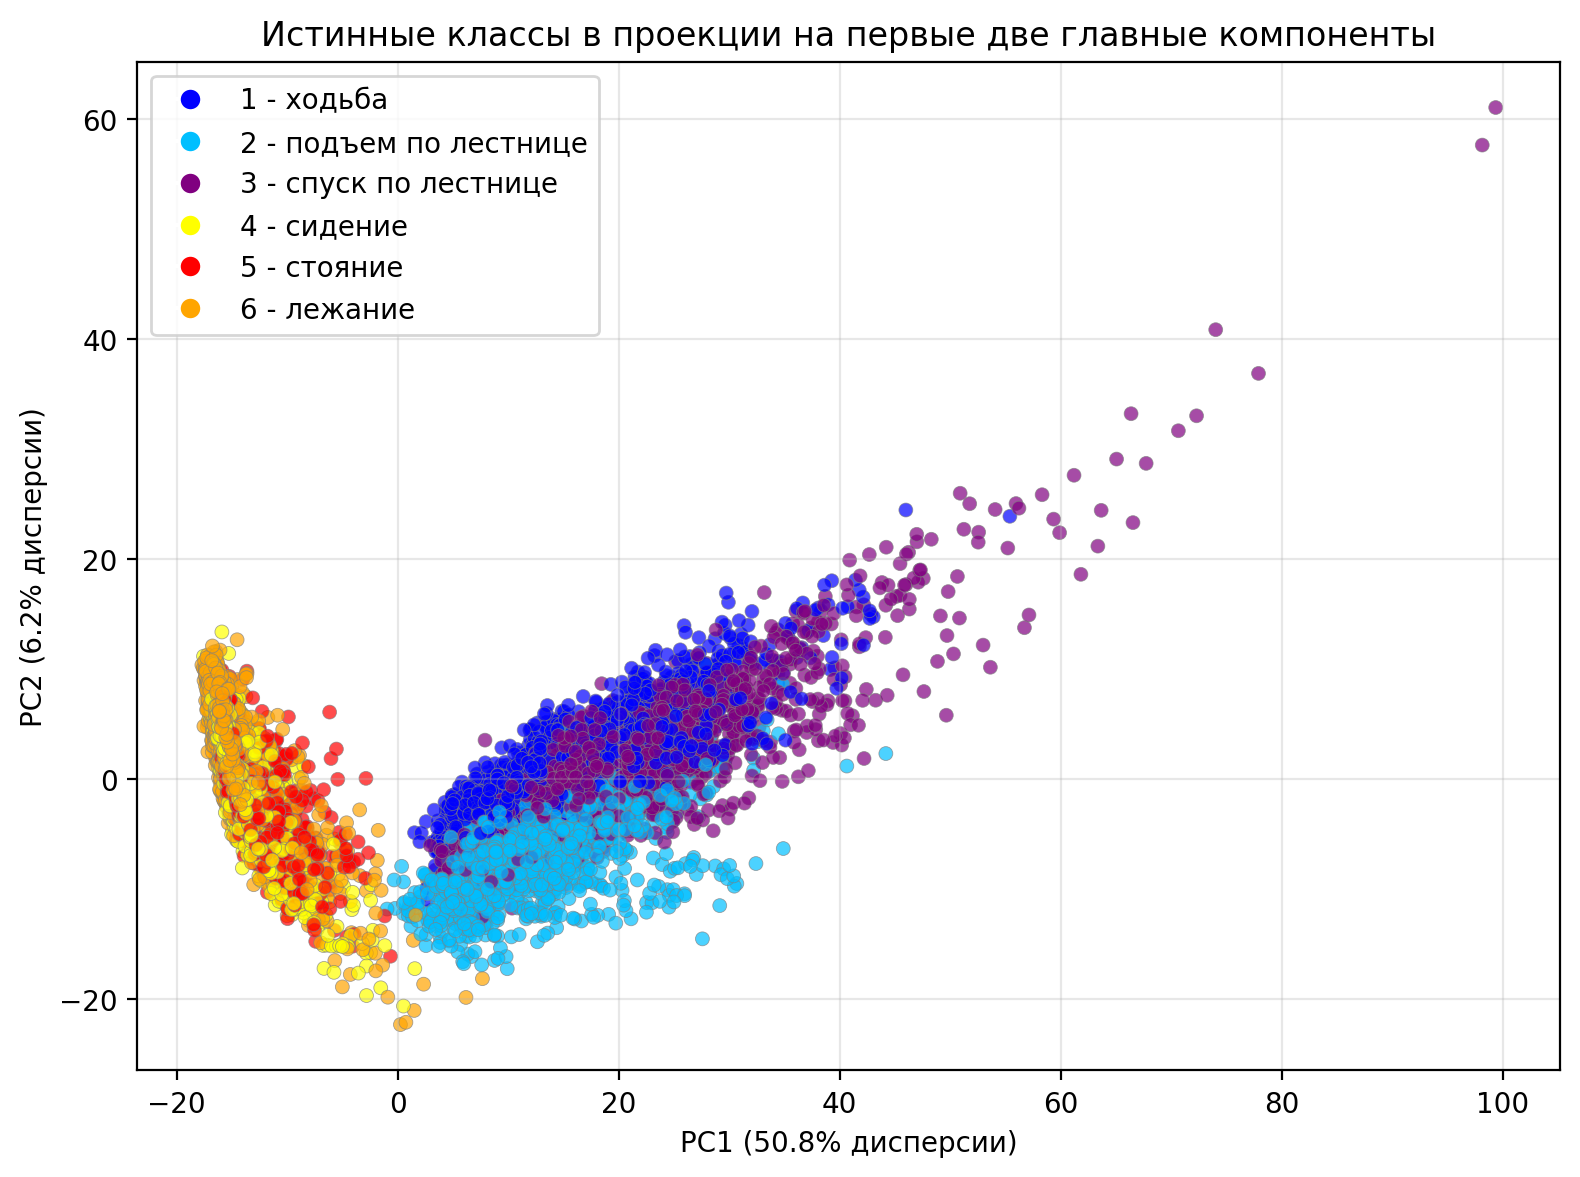

In [87]:
import matplotlib.pyplot as plt
import numpy as np

activity_colors = {
    1: 'blue',      # ходьба
    2: 'deepskyblue',  # подъем вверх по лестнице (голубой)
    3: 'purple',    # спуск по лестнице (фиолетовый)
    4: 'yellow',    # сидение
    5: 'red',       # стояние
    6: 'orange',    # лежание
}

# Массив цветов в порядке объектов
y_true = y['Activity'].values
colors_true = [activity_colors[a] for a in y_true]

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=colors_true,
    alpha=0.7,
    s=25,
    edgecolor='gray',
    linewidth=0.3
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.title('Истинные классы в проекции на первые две главные компоненты')

# Легенда по классам
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='1 - ходьба',
           markerfacecolor=activity_colors[1], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='2 - подъем по лестнице',
           markerfacecolor=activity_colors[2], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='3 - спуск по лестнице',
           markerfacecolor=activity_colors[3], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='4 - сидение',
           markerfacecolor=activity_colors[4], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='5 - стояние',
           markerfacecolor=activity_colors[5], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='6 - лежание',
           markerfacecolor=activity_colors[6], markersize=8),
]
plt.legend(handles=legend_elems, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [75]:
from sklearn.cluster import KMeans
start_time = time.time()
kmeans = KMeans(n_clusters=6,
                n_init=100,
                random_state=RANDOM_STATE)
kmeans.fit(X_pca)
train_time= time.time()-start_time

start_time= time.time()
labels= kmeans.predict(X_pca)
infer_time= time.time()-start_time

print(f'Время обучения:  {train_time} сек')
print(f'Время инференса: {infer_time} сек')
print(f'Метки кластеров: {labels[:10]}')

cluster_labels = labels

Время обучения:  10.849463939666748 сек
Время инференса: 0.003880023956298828 сек
Метки кластеров: [2 2 2 2 2 2 2 2 2 2]


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

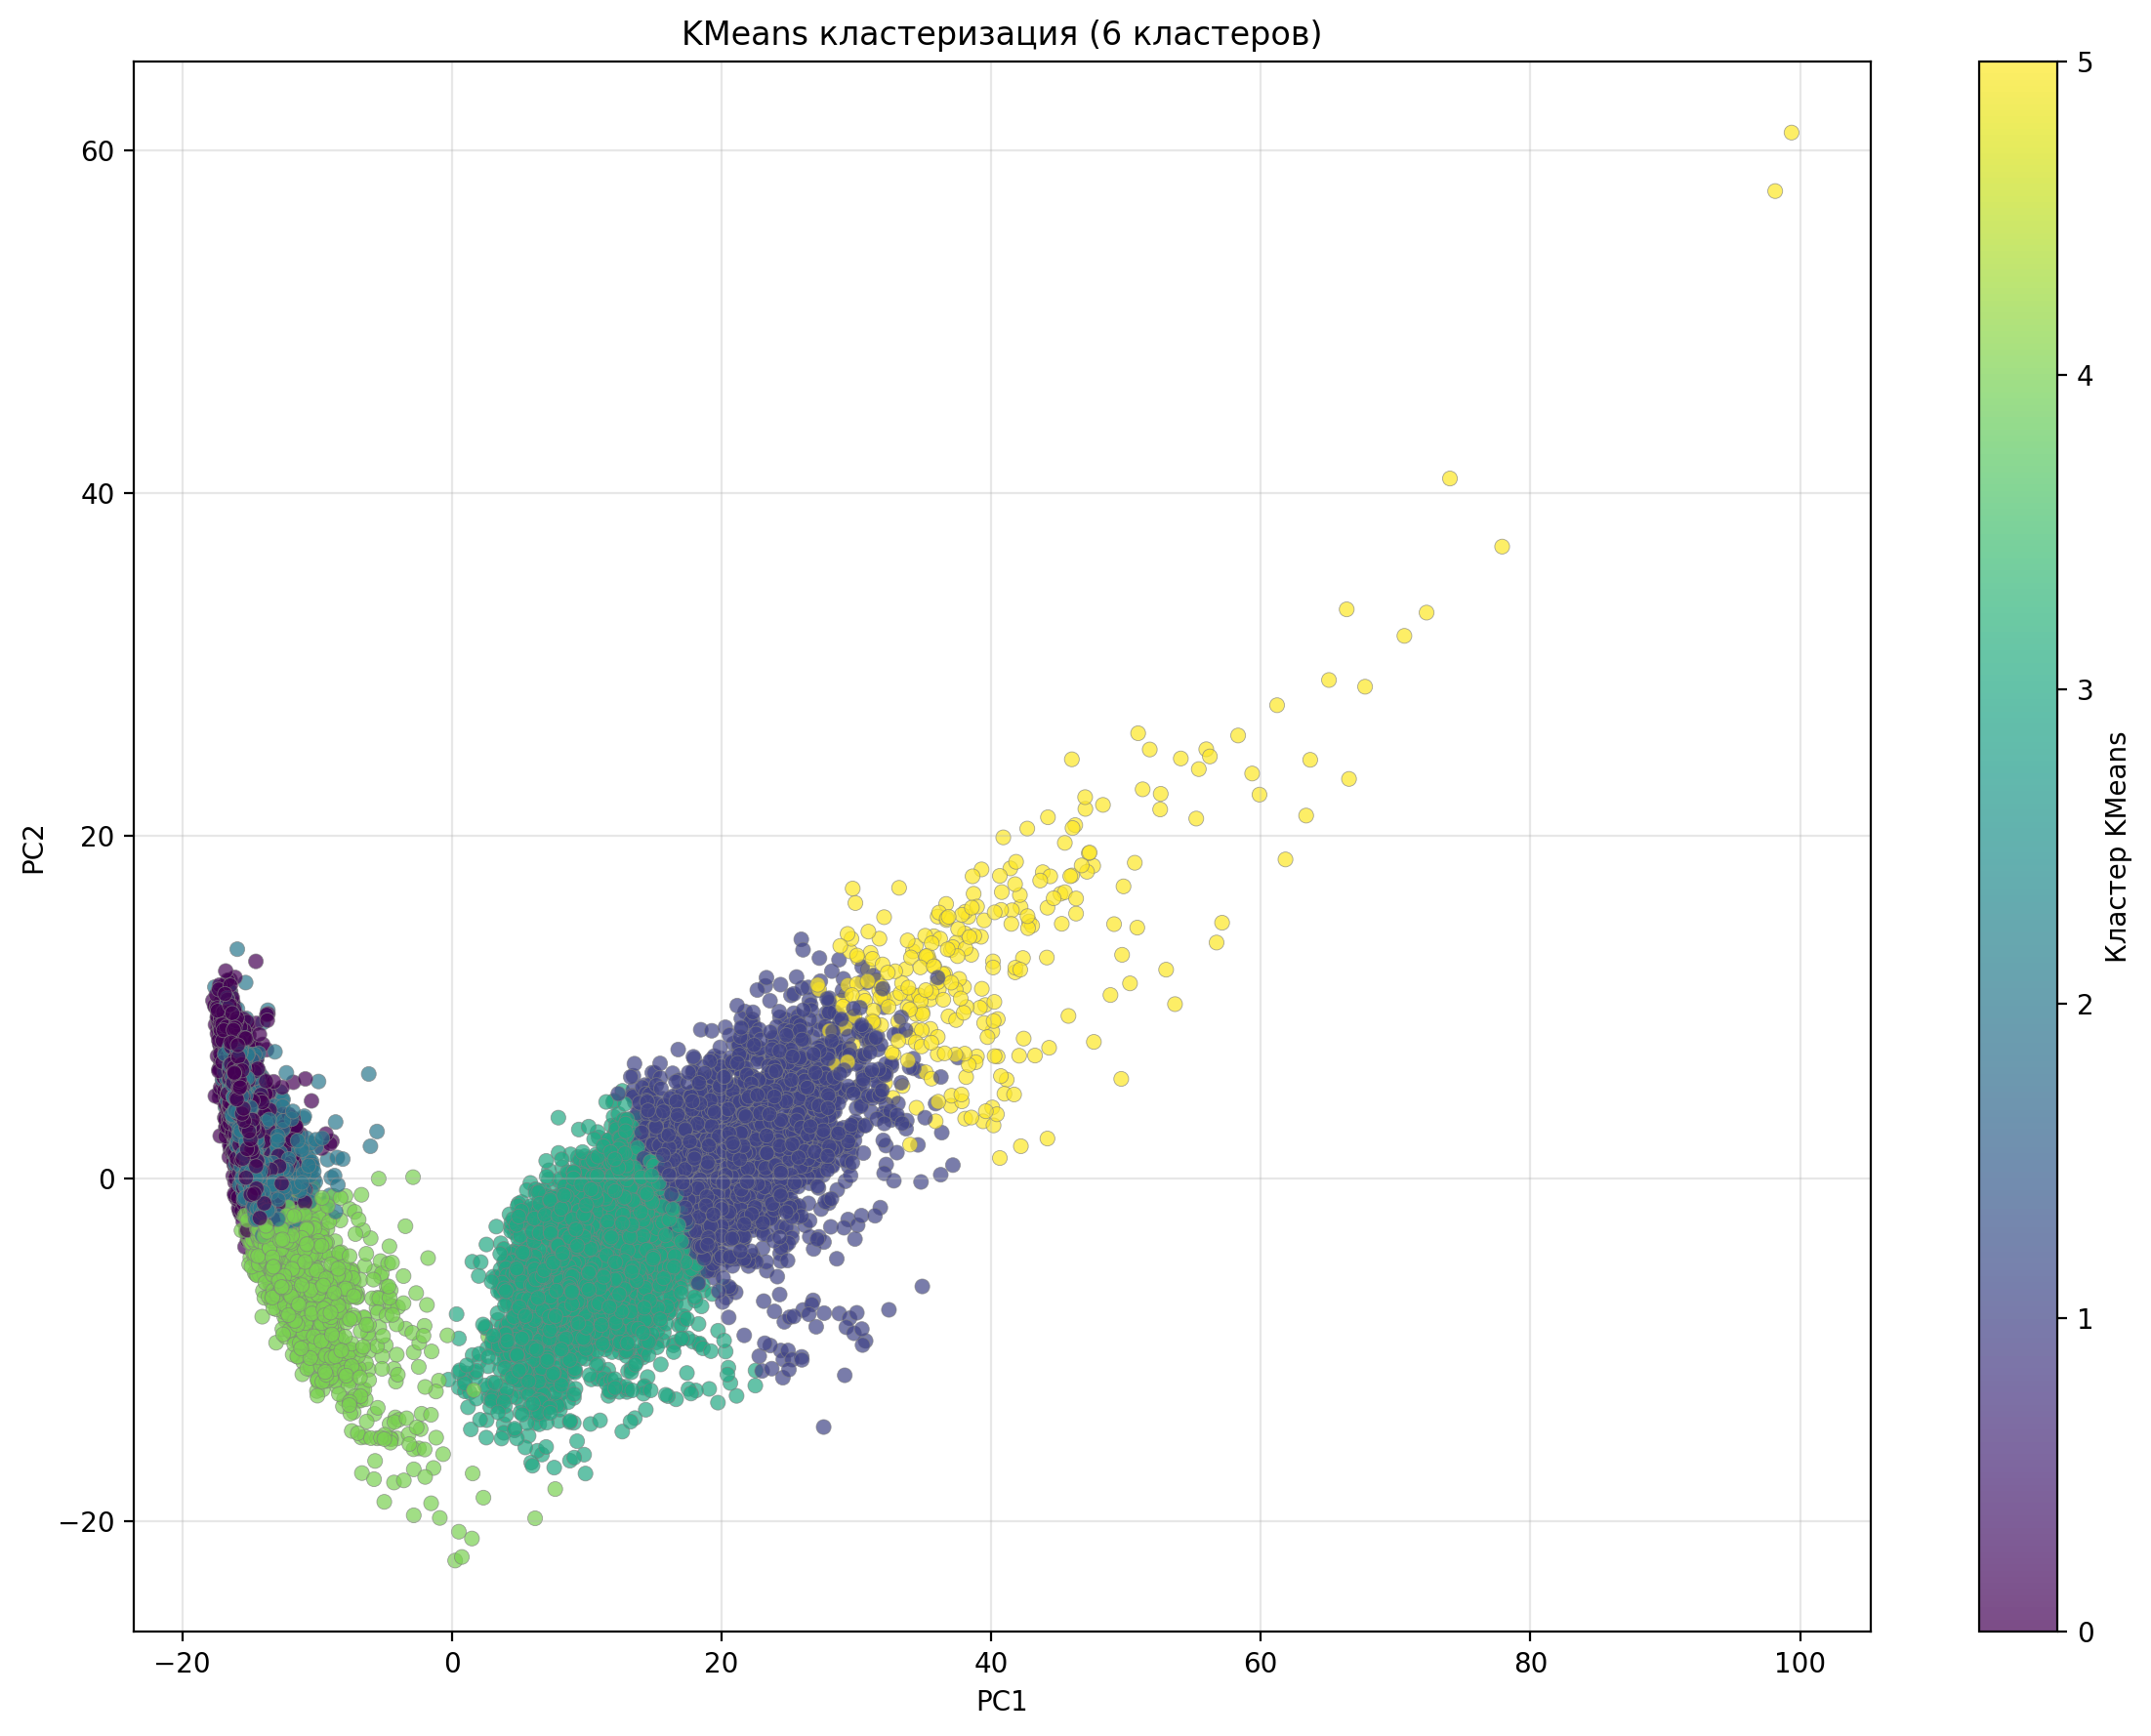

In [89]:
plt.figure(figsize=(12, 9))


scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels,
                     cmap='viridis',
                     alpha=0.7,
                     s=30,
                     edgecolor='gray',
                     linewidth=0.3)


plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.title('KMeans кластеризация (6 кластеров)')


plt.colorbar(scatter, label='Кластер KMeans')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [77]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

y_true = y['Activity'].values

ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print(f'ARI: {ari}')
print(f'NMI: {nmi}')

ARI: 0.4197099073363299
NMI: 0.5601599061934478


Обоснование выбора метрик:
ARI (Adjusted Rand Index) — измеряет, насколько разбиение на кластеры совпадает с истинными классами, плюс скорректирован на случайные совпадения

NMI (Normalized Mutual Information) — нормализованная взаимная информация между кластерами и истинными классами, в диапазоне [0,1], где 0 — независимы, 1 — полное совпадение разбиений.


**Ваш вывод здесь**
NMI = 0.56 говорит о том, что кластеры информативны. Кластеризация значительно лучше случайной (ARI > 0). Вероятно, выделены основные паттерны активности, но ARI = 0.42 указывает на проблемы с границами кластеров.


### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [78]:
from sklearn.cluster import AgglomerativeClustering
start_time = time.time()
agg = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward',
    metric='euclidean'
)
agg_labels = agg.fit_predict(X_pca)
total_time = time.time() - start_time

print(f'Время работы AgglomerativeClustering: {total_time:.3f} сек')
print('Первые метки кластеров:', agg_labels[:10])


Время работы AgglomerativeClustering: 18.632 сек
Первые метки кластеров: [5 5 5 5 5 5 5 5 5 5]


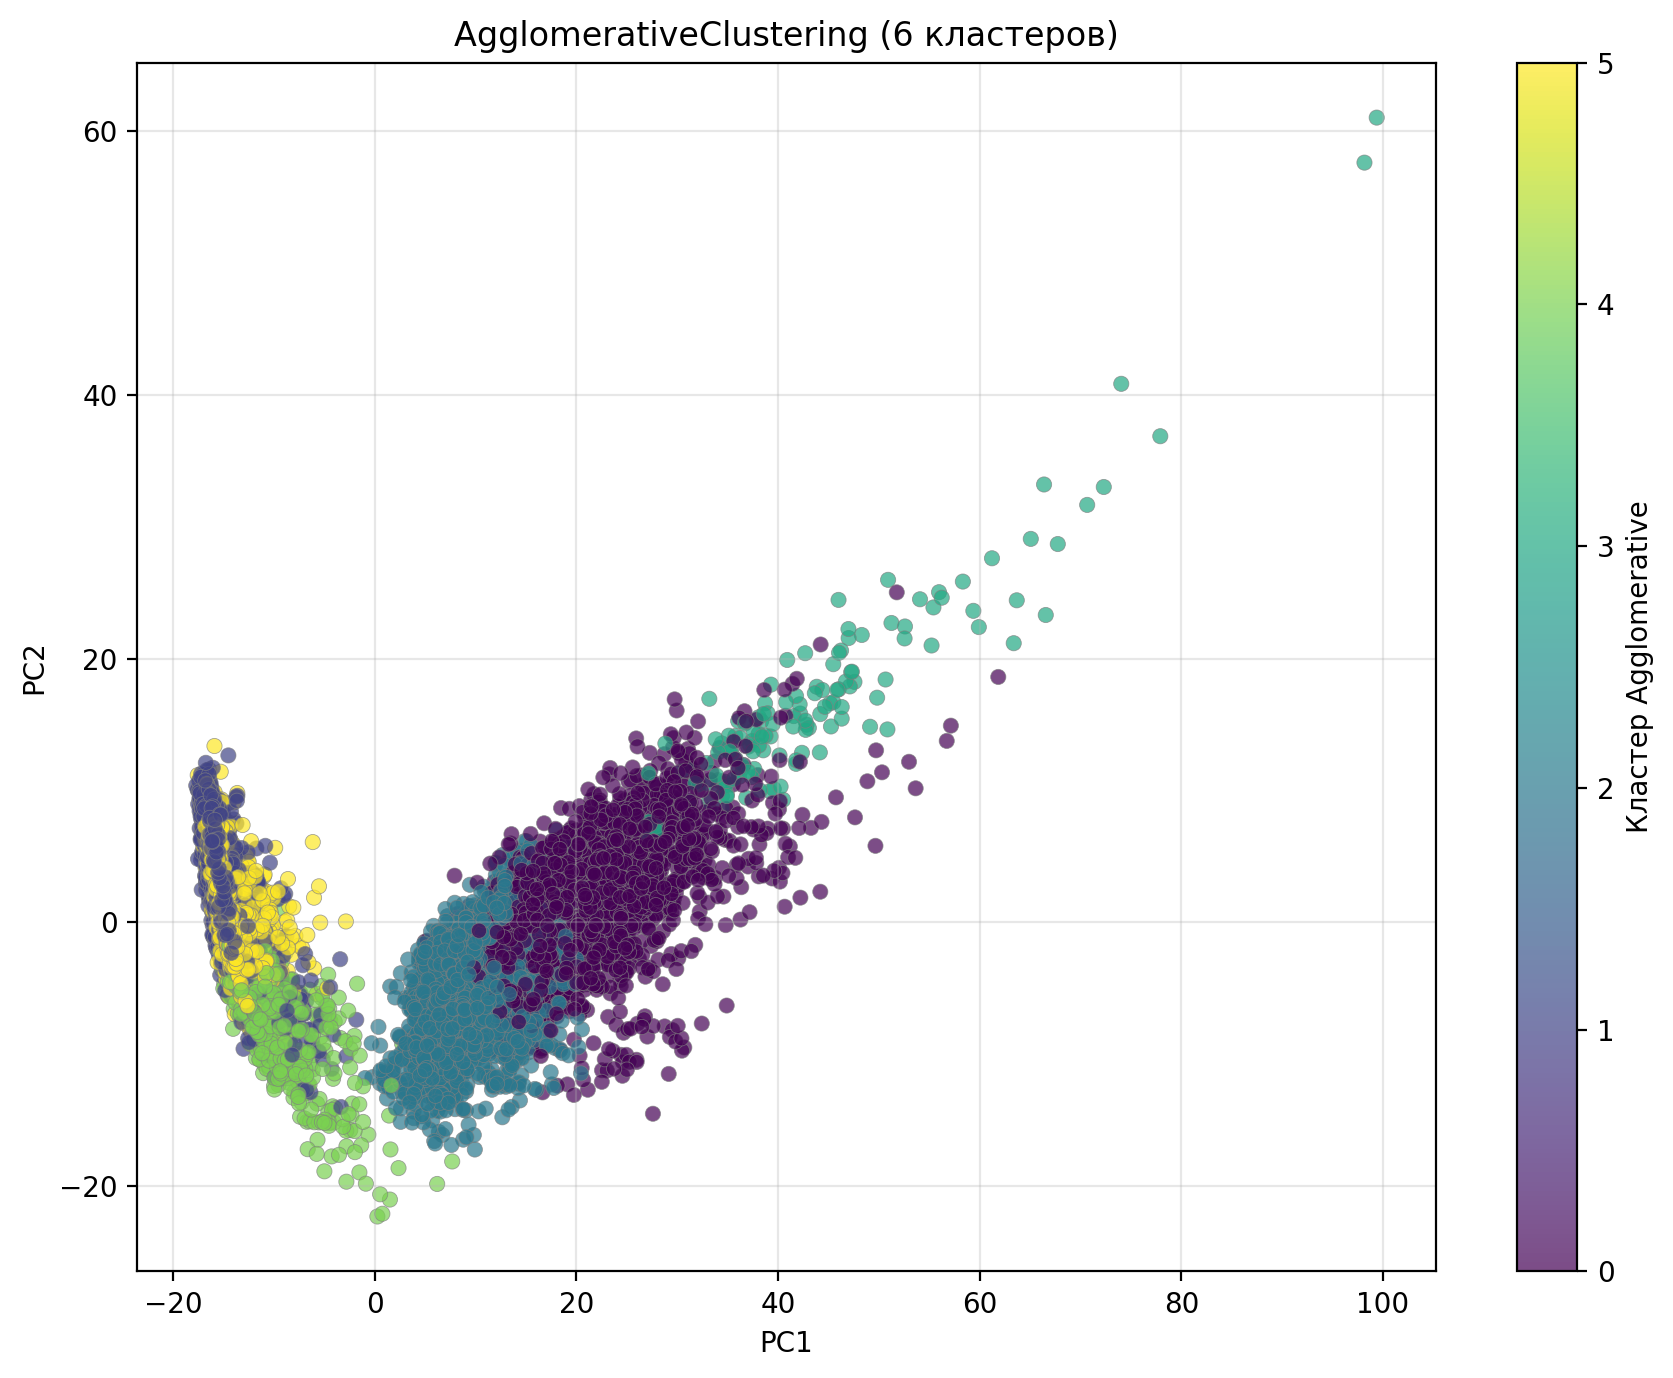

In [82]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=agg_labels,
    cmap='viridis',
    alpha=0.7,
    s=30,
    edgecolor='gray',
    linewidth=0.3
)

plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.title('AgglomerativeClustering (6 кластеров)')
plt.colorbar(scatter, label='Кластер Agglomerative')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [81]:
agg_ari = adjusted_rand_score(y_true, agg_labels)
agg_nmi = normalized_mutual_info_score(y_true, agg_labels)

print(f'Agglomerative ARI: {agg_ari:.3f}')
print(f'Agglomerative NMI: {agg_nmi:.3f}')

Agglomerative ARI: 0.482
Agglomerative NMI: 0.613


**Ваш вывод здесь**

Для AgglomerativeClustering получилось ARI = 0.482 и NMI = 0.613 — это заметно лучше, чем у KMeans (ARI = 0.420, NMI = 0.560).

ARI вырос с 0.420 до 0.482 — кластеры и истинные классы согласованы сильнее.

NMI вырос с 0.560 до 0.613 — кластеры содержат больше информации о настоящих активностях.

При этом цена — большее время работы (18.6с против 11.8с).

Иерархическая агломеративная кластеризация с linkage='ward' иногда лучше подходит к структуре данных после PCA, чем KMeans.  Ward‑связка минимизирует внутрикластерную дисперсию на каждом шаге слияния и строит «дерево» кластеров. Плюс в отличие от KMeans, нет случайной инициализации центроидов — результат стабилен, и модель не портится из‑за неудачных начальных центров.


### **Задание 23 (0.3 балла)**
Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* Похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* В каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* Качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

**Ваш вывод здесь**

1. По значениям ARI и NMI видно, что кластеры существенно коррелируют с реальными классами, но не идеально.

Объекты внутри каждого кластера  похожи на определенный тип активности, но с некоторыми оговорками.  Глядя на график видно два больших облака точек (левое облако - PC<0 и правое облако PC>O). В левом облаке точки сине-фиолетовые (кластер 1), желтые (кластер 5) и зеленые (кластер 4). Похоже, что данное облако соответствует статичным видам активности (сидение/стояние/лежание). Когда человек не движется, смартвон фиксирует только вектор гравитации, поэтому данные очень похожи друг на друга и дисперсия мала.

В правом облаке точки фиолетовые (кластер 0), бирюзовые (кластер 3) и синие (кластер 2) - динамичные виды активности (ходьба, спуск и подъем). Датчики фиксируют ускорение тема, что создает большой разброс данных.

По сути модель выявила разницу между покоем и движением, но внутри групп кластеры выявлены не идеально.


2. В каких кластерах смешано несколько активностей и почему?

Смешивание почти неизбежно в следующих случаях:

Ходьба / подъём / спуск по лестнице
Эти три класса очень похожи: ритмичные шаги, близкие частоты, схожие амплитуды.
Модель без меток видит «семейство» похожих траекторий и тяготеет к объединению их в 2–3 кластера с перемешанными метками.

Сидение/ стояние/лежание
Сигнал часто почти статичен в обоих случаях: телефон в кармане, малые ускорения, различия в основном в ориентации тела. PCA и кластеризация могут считать их одним типом активности и смешивать в один-два кластера.


3. Насколько качественная кластеризация и на чём основан вывод?

ARI= 0.48 и NMI= 0.61 означают, что кластеры существенно лучше случайных и заметно соотносятся с реальными активностями. Но результат посредственный.


## **Бонус-задание (1 балл)**
![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных задачах. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. В бонусе предлагаем вам попрактиковаться именно в этом на чудесной утке и совах (```duck.jpg``` и ```owls.jpg```)

### **(0.1 балл)**

- Откройте изображения, после чего визуализируйте их с помощью ```plt.imshow()```

In [ ]:
from PIL import Image
# or
#import cv2

### **(0.4 балла)**

Для каждого изображения, используя кластеризацию ```KMeans```, выделите компоненты, охарактеризовав каждый пиксель следующим образом: $$\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$$
 где
- $x_i$ и $y_i$ — координаты пикселя,
- $r_i, g_i, b_i$ — его цвет,
- $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

Примените полученную функцию, взяв следующие $\lambda$: 0.3 и 1.5 для ```duck.jpg``` и ```owls.jpg``` (или другие, но тогда с вас красивые результаты :) )

**Примечание:**
Число кластеров подберите разумным образом на свой вкус (в качестве нулевого приближения можно взять 3)

In [ ]:
def find_components(image, lmbd, n_clusters):
    #your code here

### **(0.4 балла)**

Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).


**Примечание:**

Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**Подсказка:**```skimage``` с его ```color``` и ```transform``` в этом помогут :)

Или же воспользуйтесь аналогичными средствами ```PIL``` или ```cv2```

In [ ]:
def spectral_segmentation(image, n_clusters, beta, eps):
    #your code here

### **(0.1 балл)**
Визуализируйте результаты сегментации (аналогично рисунку в начале задания 2) для обоих методов.

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

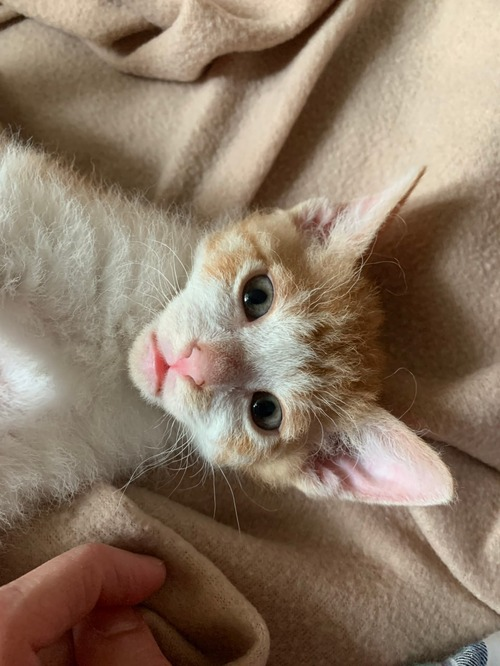